In [41]:
from PyHessian.pyhessian.hessian import hessian
from PyHessian.density_plot import get_esd_plot
from hessian_utils import *
from PyHessian.pyhessian.utils import *
import torch
import torch.nn as nn
import numpy as np
from torchvision import datasets, transforms
# from keras.datasets import mnist
import matplotlib.pyplot as plt 
import time
import copy


# PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True
import os

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
%matplotlib inline

In [42]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(device)
cuda = torch.cuda.is_available()
torch.autograd.set_detect_anomaly(True)

cpu


In [43]:
mnist_trainset = datasets.MNIST(root='../data/mnist', train=True, download=True, transform=transforms.ToTensor())
mnist_fashion_trainset = datasets.FashionMNIST(root='../data/fashion_mnist', train=True, download=True, transform=transforms.ToTensor())
cifar_trainset = datasets.CIFAR10(root='../data/cifar10', train=True, download=True, transform=transforms.ToTensor())
# Getting mnist test data
mnist_testset = datasets.MNIST(root='../data/mnist', train=False, download=True, transform=transforms.ToTensor())
mnist_fashion_testset = datasets.FashionMNIST(root='../data/fashion_mnist', train=False, download=True, transform=transforms.ToTensor())
cifar_testset = datasets.CIFAR10(root='../data/cifar10', train=False, download=True, transform=transforms.ToTensor())

torch.manual_seed(42)

Files already downloaded and verified
Files already downloaded and verified


In [44]:
train_X = cifar_trainset.data
train_y = cifar_trainset.targets
test_X = cifar_testset.data
test_y = cifar_testset.targets

In [45]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(28*28, 100)
        self.fc2 = nn.Linear(100, 30)
        self.fc3 = nn.Linear(30, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 10, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(10, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.linear = nn.Sequential(
            nn.Linear(16*7*7, 16),
            nn.ReLU(),
            nn.Linear(16, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(-1, 16*7*7)
        x = self.linear(x)
        return x

class ConvNet3D(nn.Module):
    def __init__(self):
        super(ConvNet3D, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 20, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(20, 40, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.linear = nn.Sequential(
            nn.Linear(40*8*8, 30),
            nn.ReLU(),
            nn.Linear(30, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(-1, 40*8*8)
        x = self.linear(x)
        return x

In [46]:
# train_X = (train_X / 255.0).to(device)
# test_X = (test_X / 255.0).to(device)
# train_y = torch.tensor(train_y, dtype=torch.int64).to(device)
# test_y = torch.tensor(test_y, dtype=torch.int64).to(device)

train_X = torch.tensor(train_X).permute(0, 3, 1, 2).float()
test_X = torch.tensor(test_X).permute(0, 3, 1, 2).float()
train_X = (train_X / 255.0).to(device)
test_X = (test_X / 255.0).to(device)
train_y = torch.tensor(train_y, dtype=torch.int64).to(device)
test_y = torch.tensor(test_y, dtype=torch.int64).to(device)

In [47]:
dataloader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(train_X[:1000], train_y[:1000]),
    batch_size=32, shuffle=True)


hessian_loader = (train_X[:50], train_y[:50])

# hessian_loader contains 50 images
# for i in range(50):
#     hessian_loader.append((train_X[i].unsqueeze(0), train_y[i].unsqueeze(0)))

In [48]:
model_base = ConvNet3D().to(device)
model_SGD = copy.deepcopy(model_base)
model_Adam = copy.deepcopy(model_base)
model_curvy = copy.deepcopy(model_base)

criterion = nn.CrossEntropyLoss()
optimizer_SGD = torch.optim.SGD(model_SGD.parameters(), lr=1e-2)
optimizer_Adam = torch.optim.Adam(model_Adam.parameters(), lr=1e-2)
optimizer_curvy = torch.optim.SGD(model_curvy.parameters(), lr=1e-2)

In [49]:
train_losses_SGD = []
train_losses_Adam = []
train_losses_curvy = []
traces_SGD = []
traces_Adam = []
traces_curvy = []
epochs = 30
n_iter = 10

In [50]:
# curvature_SGD = []
# curvature_Adam = []

hessian_SGD = hessian(model_SGD, criterion, data = hessian_loader, cuda=cuda)
hessian_Adam = hessian(model_Adam, criterion, data = hessian_loader, cuda=cuda)
hessian_curvy = hessian(model_curvy, criterion, data = hessian_loader, cuda=cuda)

curvature_SGD = (hessian_SGD.curvature_array(n_iter, 1e-3))
curvature_Adam = (hessian_Adam.curvature_array(n_iter, 1e-3))
curvature_curvy = (hessian_curvy.curvature_array(n_iter, 1e-3))

# mean_curvature_SGD = [torch.mean(torch.stack(curvature_SGD[:][i]), dim = 0) for i in range(len(curvature_SGD[0]))]
# mean_curvature_Adam = [torch.mean(torch.stack(curvature_Adam[:][i]), dim = 0) for i in range(len(curvature_Adam[0]))]



In [51]:
def plot_curvature(curvature, blocks = None, nodesin = None, title = 'Curvature'):
    # Add incides of parameter blocks to the plot
    

    if blocks is not None:
        flattened_curvature = np.concatenate([np.array(c).flatten() for c in [curvature[block] for block in blocks]])
        numels = [curvature[block].size for block in blocks]
        indices = [0] + np.cumsum(numels)

    else:
        flattened_curvature = np.concatenate([np.array(c).flatten() for c in curvature])
        numels = [curvature[i].size for i in range(len(curvature))]
        indices = [0] + np.cumsum(numels)
        
    

    for i in range(len(indices)):
        plt.axvline(x=indices[i], color='r', linestyle='--', label=f'Block {i+1}')
    
    plt.plot(flattened_curvature, label="Curvature")
    plt.xlabel('Index')
    plt.ylabel('Curvature Value')
    plt.title(title)
    # plt.legend()
    plt.show()

def mean_curvature(curvature):
    return [np.mean([curvature[i][j] for i in range(len(curvature))], axis = 0) for j in range(len(curvature[0]))]

def distance(model1, model2):
    return sum([torch.norm(p1 - p2) for p1, p2 in zip(model1.parameters(), model2.parameters())])


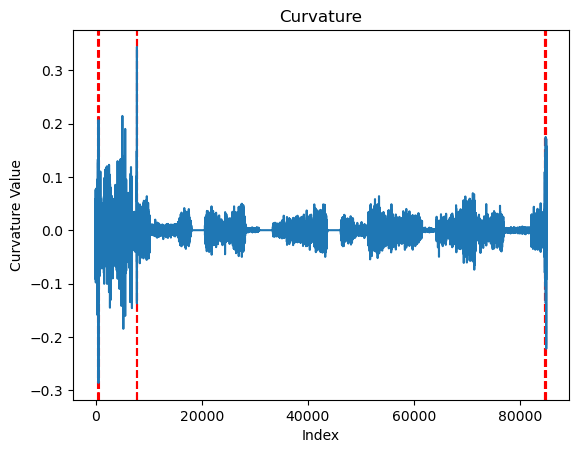

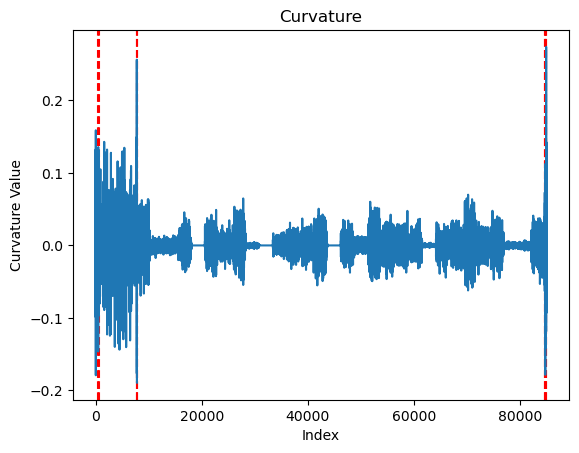

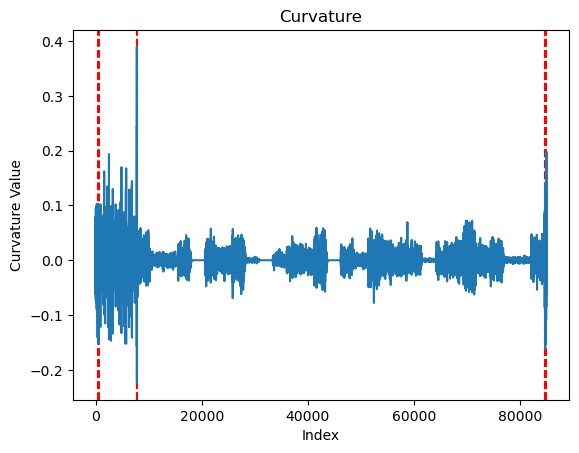

In [52]:
mean_curvature_SGD = mean_curvature(curvature_SGD)
mean_curvature_Adam = mean_curvature(curvature_Adam)
mean_curvature_curvy = mean_curvature(curvature_curvy)

model_distance_SGD = []
model_distance_Adam = []
model_distance_curvy = []

model_distance_SGD.append(distance(model_SGD, model_base))
model_distance_Adam.append(distance(model_Adam, model_base))
model_distance_curvy.append(distance(model_curvy, model_base))


plot_curvature(mean_curvature_SGD)
plot_curvature(mean_curvature_Adam)
plot_curvature(mean_curvature_curvy)

Epoch [1/30], Loss SGD: 2.3049, Loss Adam: 2.3072, loss Curvy: 2.3396


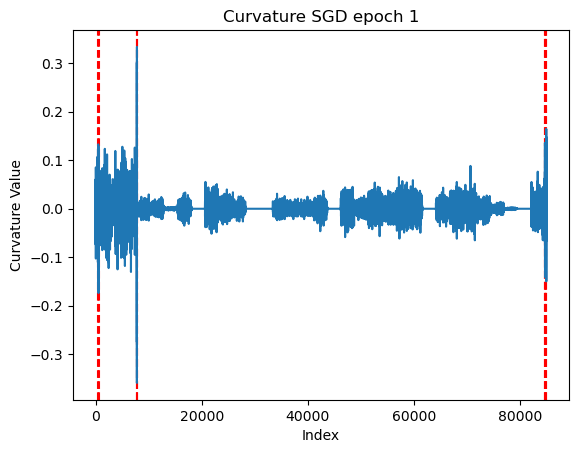

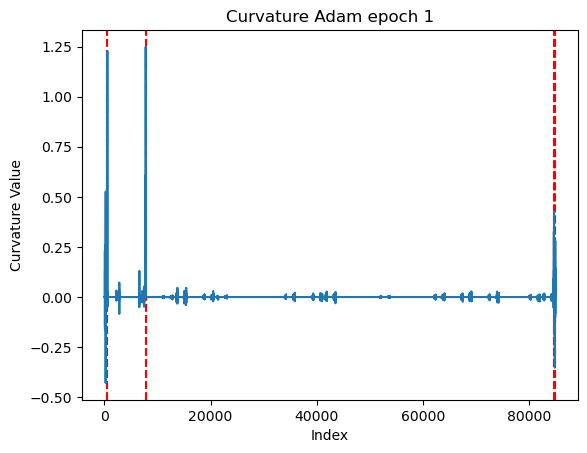

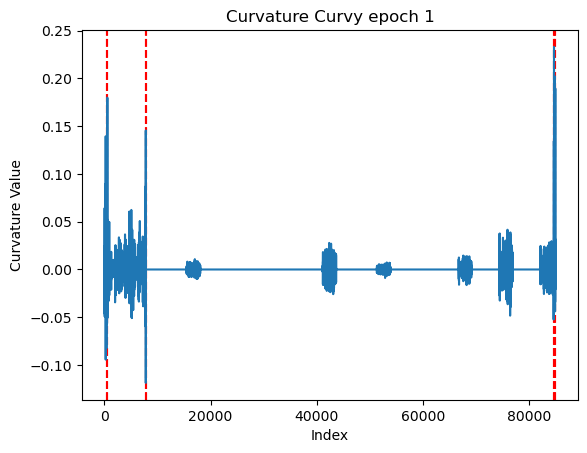

Epoch [2/30], Loss SGD: 2.3039, Loss Adam: 2.1791, loss Curvy: 2.2856


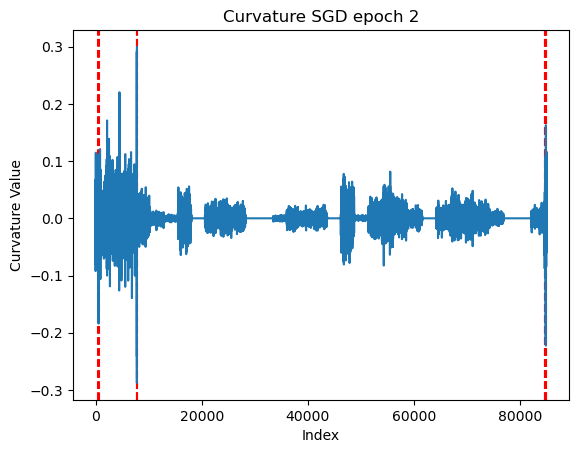

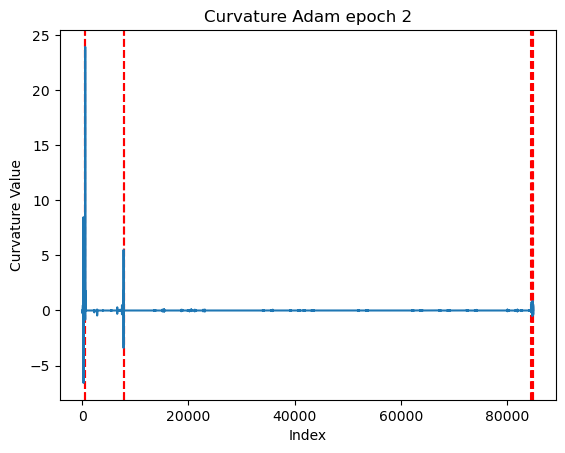

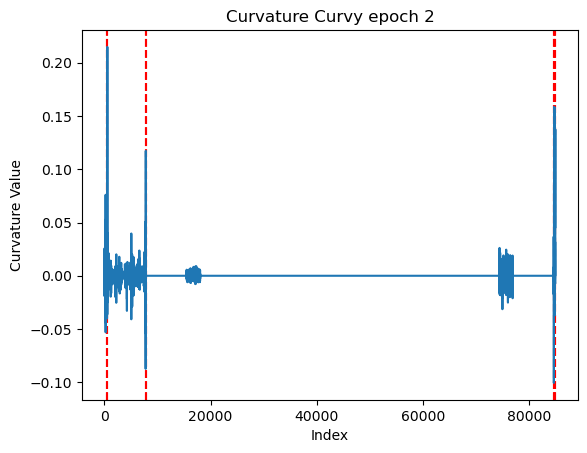

Epoch [3/30], Loss SGD: 2.3024, Loss Adam: 2.0273, loss Curvy: 1.9702


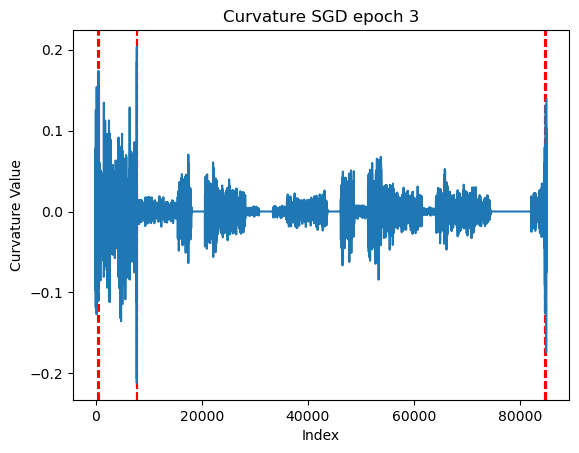

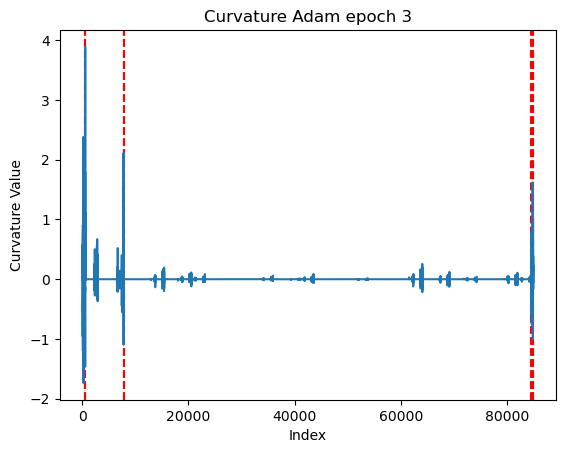

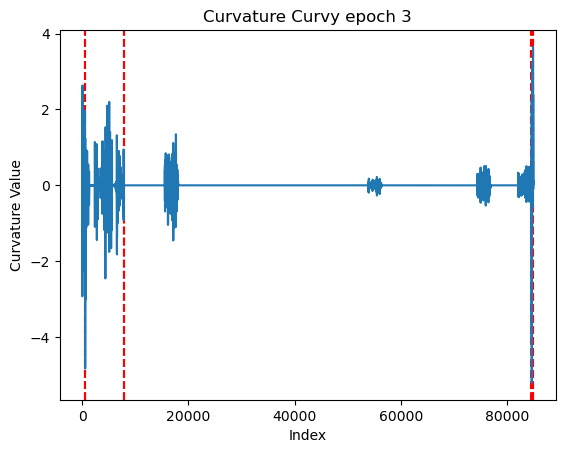

Epoch [4/30], Loss SGD: 2.3020, Loss Adam: 1.9666, loss Curvy: 2.0178


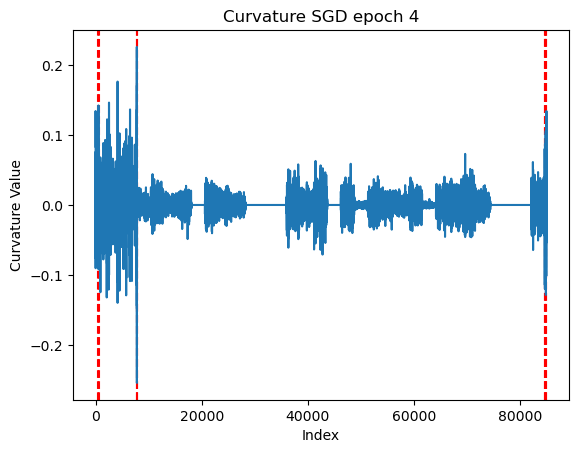

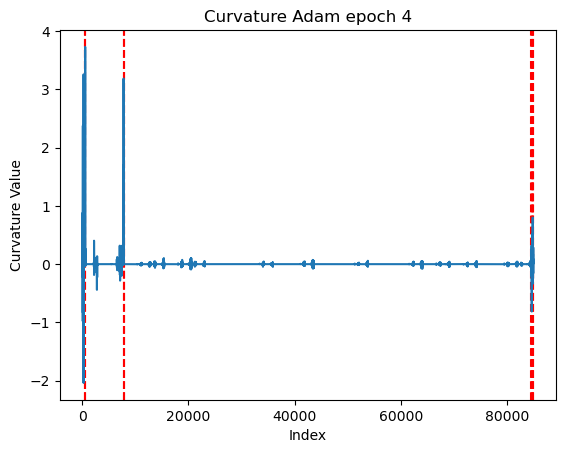

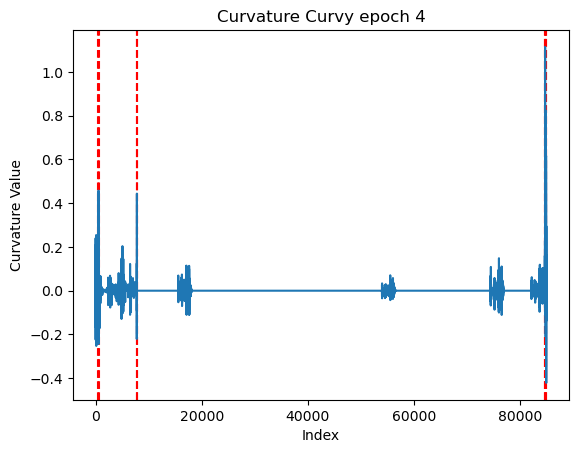

Epoch [5/30], Loss SGD: 2.3028, Loss Adam: 1.8437, loss Curvy: 2.0573


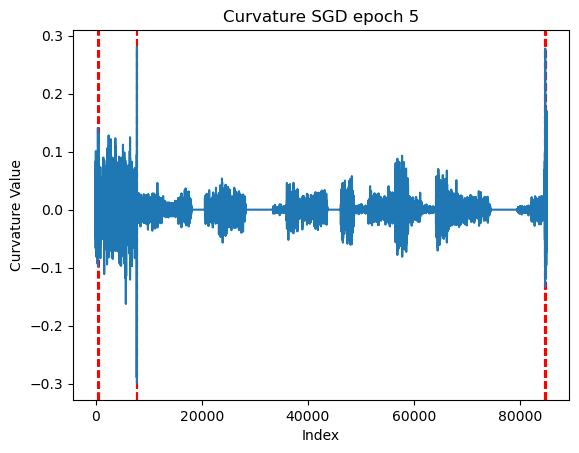

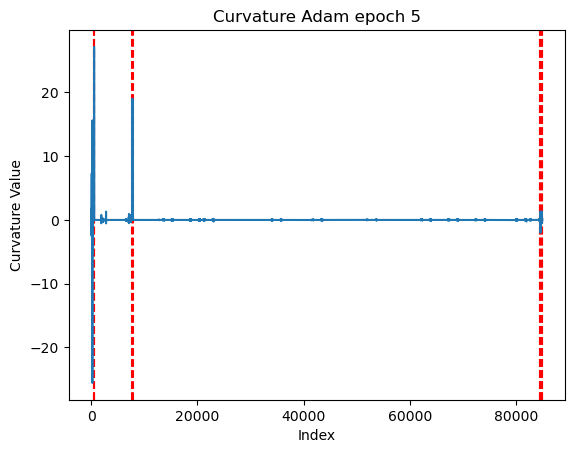

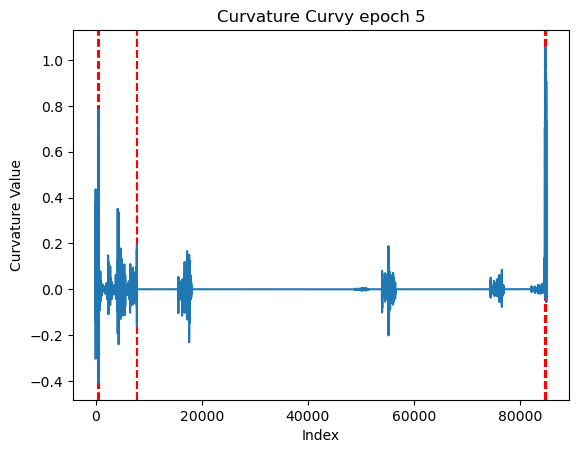

Epoch [6/30], Loss SGD: 2.3016, Loss Adam: 1.7446, loss Curvy: 2.4266


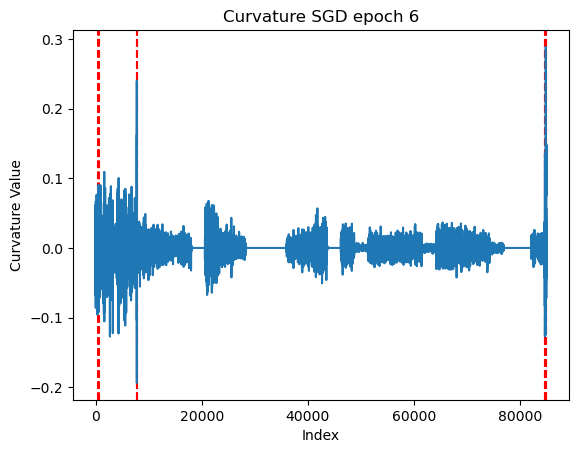

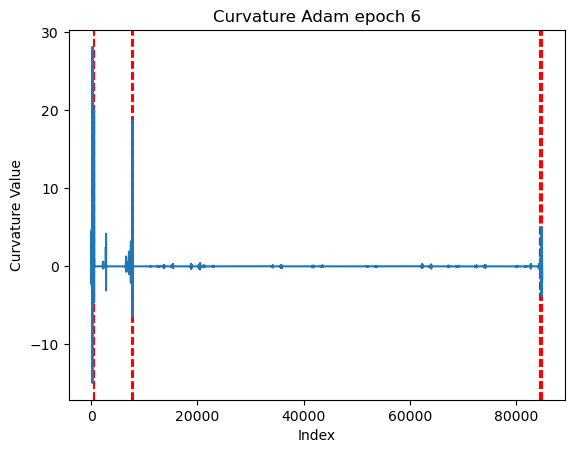

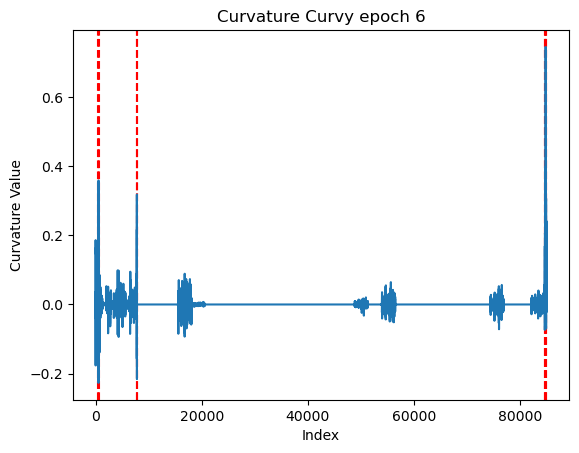

Epoch [7/30], Loss SGD: 2.3014, Loss Adam: 1.6897, loss Curvy: 2.1863


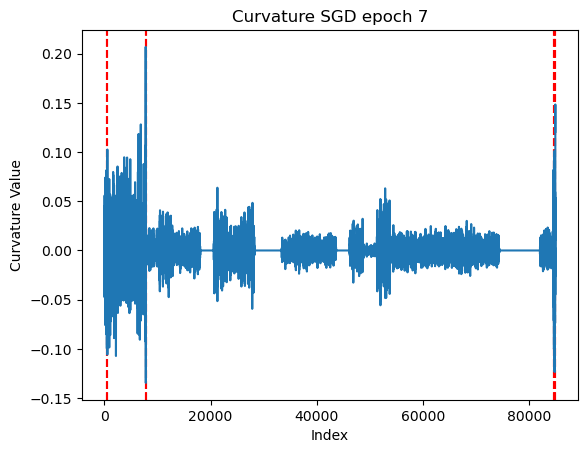

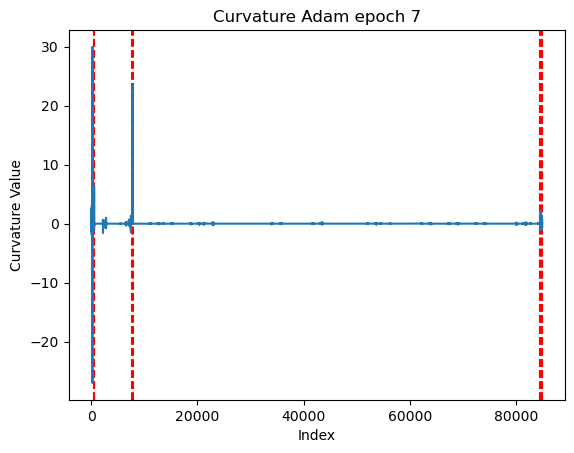

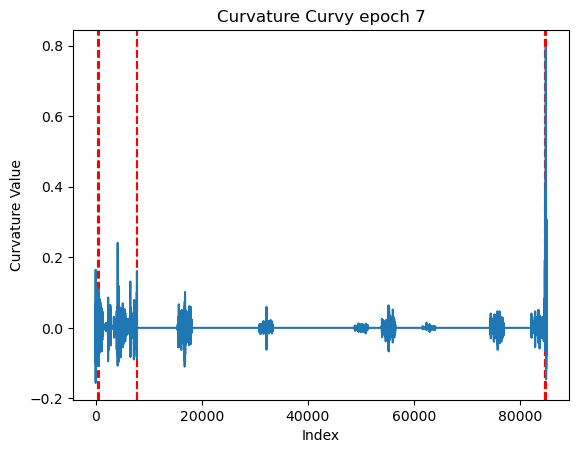

Epoch [8/30], Loss SGD: 2.3000, Loss Adam: 1.5604, loss Curvy: 1.9617


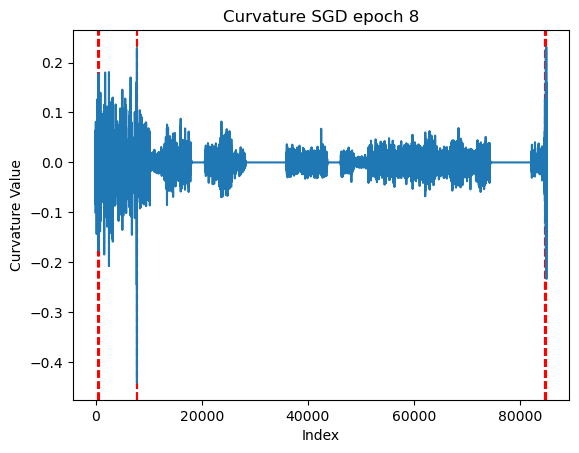

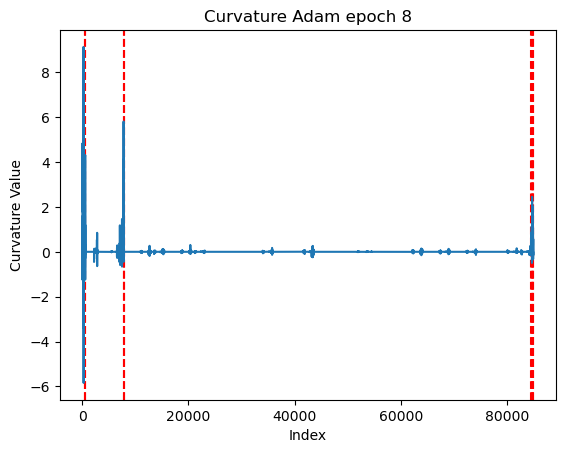

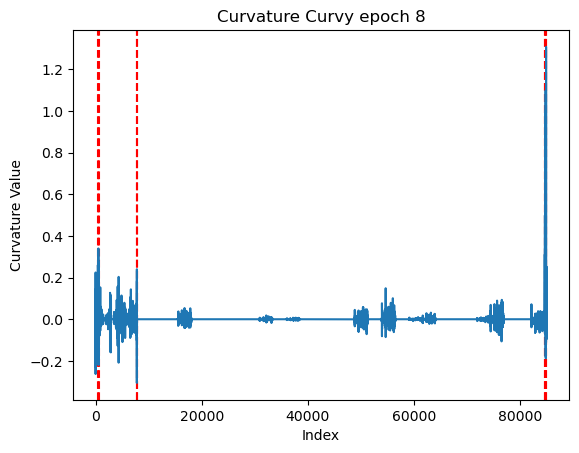

Epoch [9/30], Loss SGD: 2.2995, Loss Adam: 1.5459, loss Curvy: 2.6135


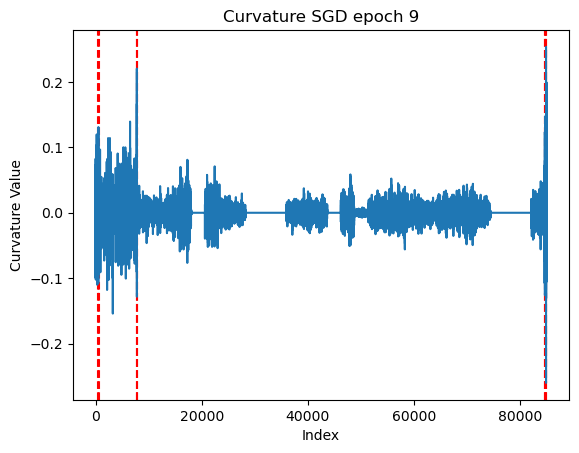

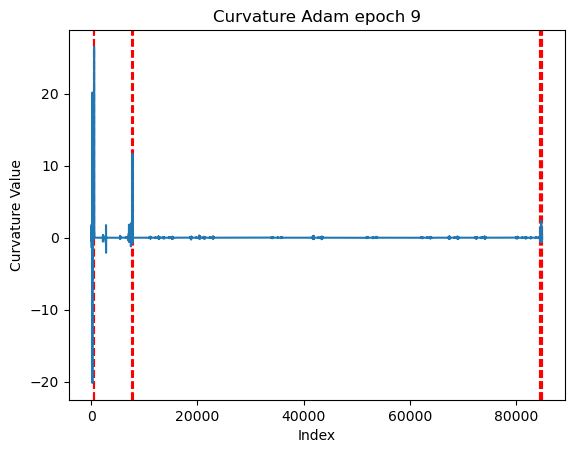

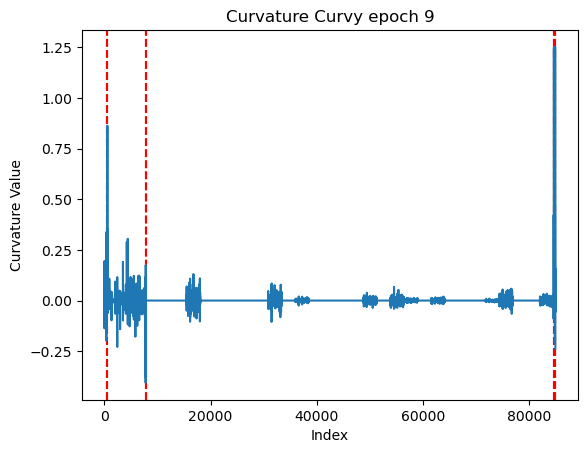

Epoch [10/30], Loss SGD: 2.2973, Loss Adam: 1.3954, loss Curvy: 1.8614


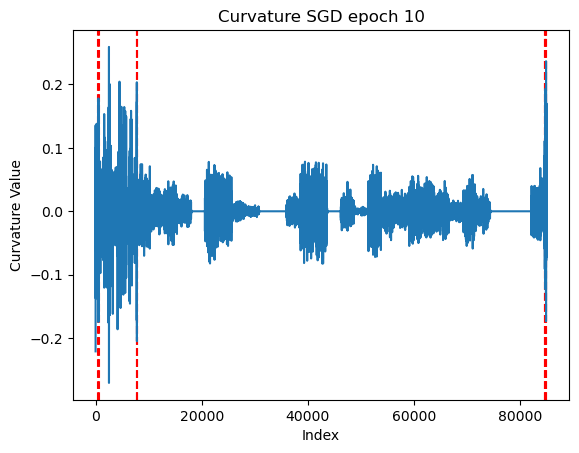

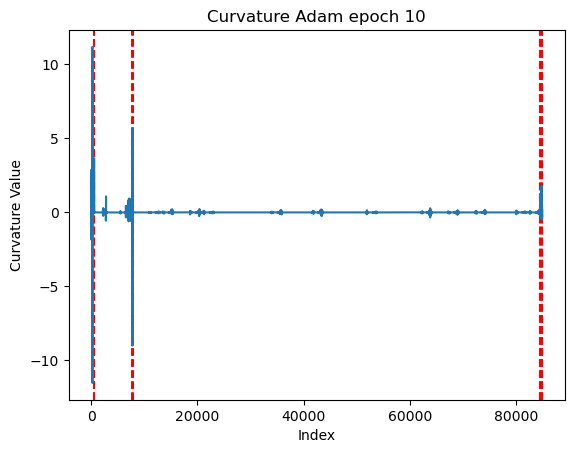

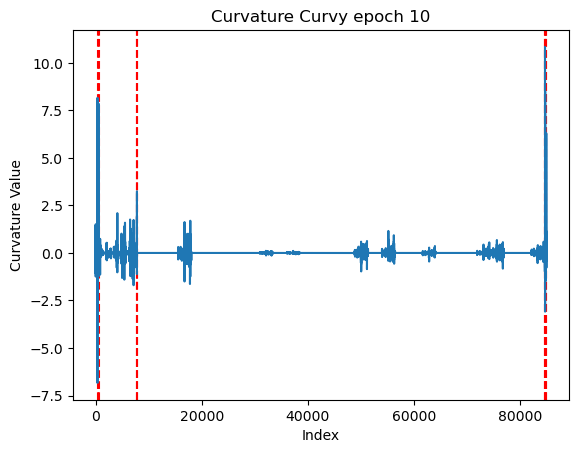

Epoch [11/30], Loss SGD: 2.2966, Loss Adam: 1.2968, loss Curvy: 2.1179


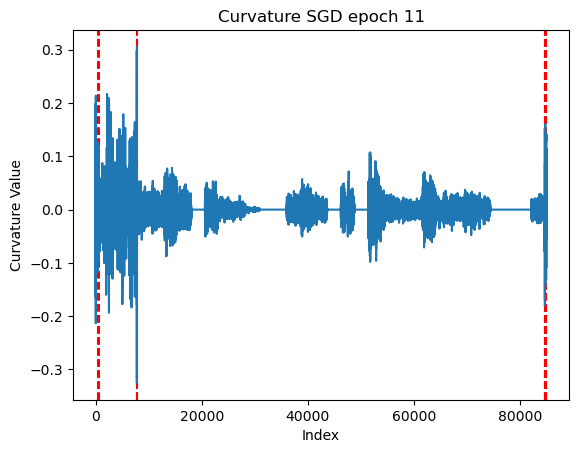

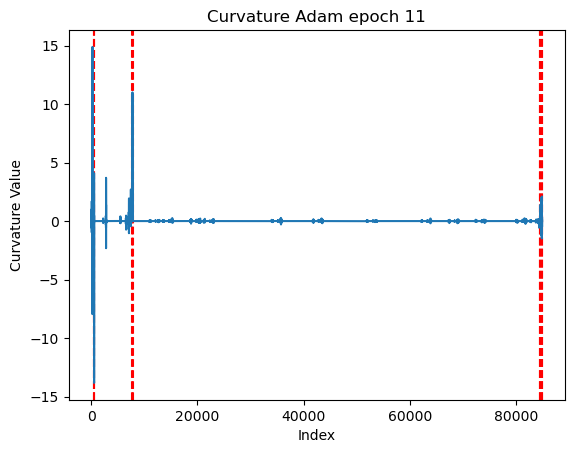

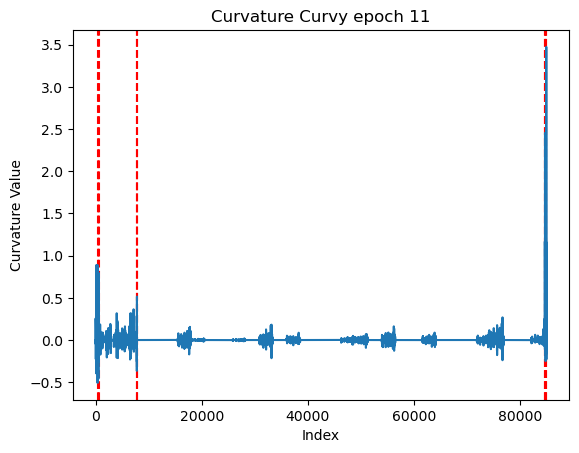

Epoch [12/30], Loss SGD: 2.2949, Loss Adam: 1.1760, loss Curvy: 1.2226


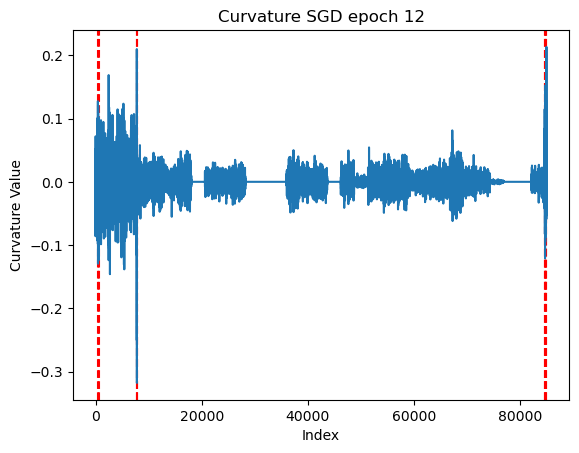

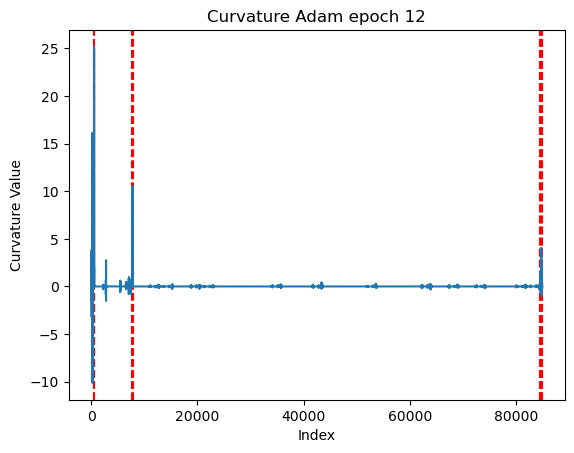

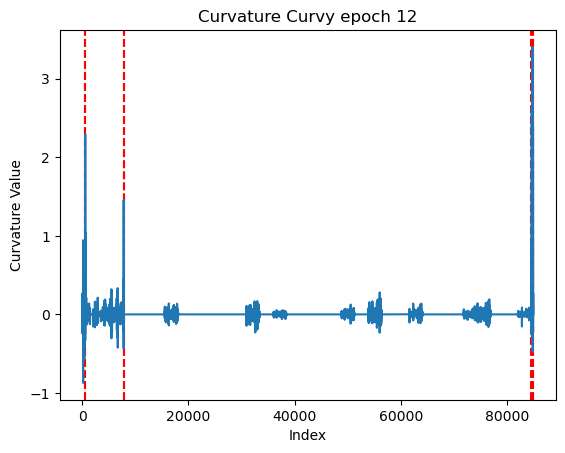

Epoch [13/30], Loss SGD: 2.2940, Loss Adam: 1.0953, loss Curvy: 1.2308


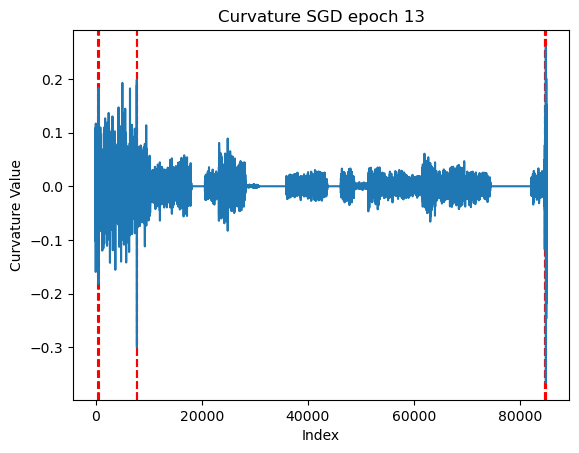

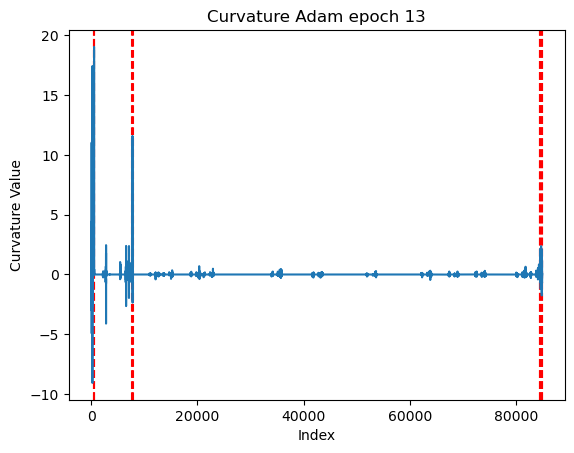

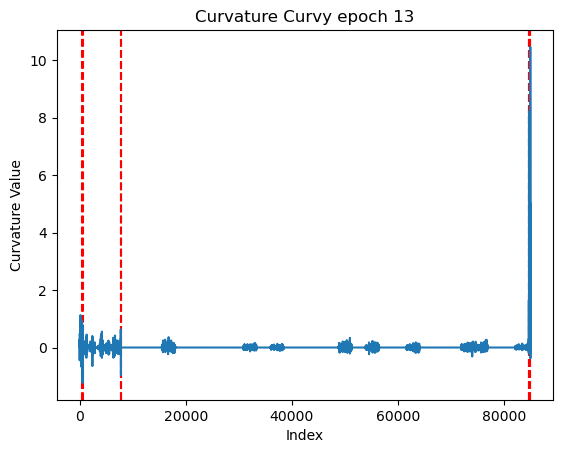

Epoch [14/30], Loss SGD: 2.2933, Loss Adam: 1.0295, loss Curvy: 1.5987


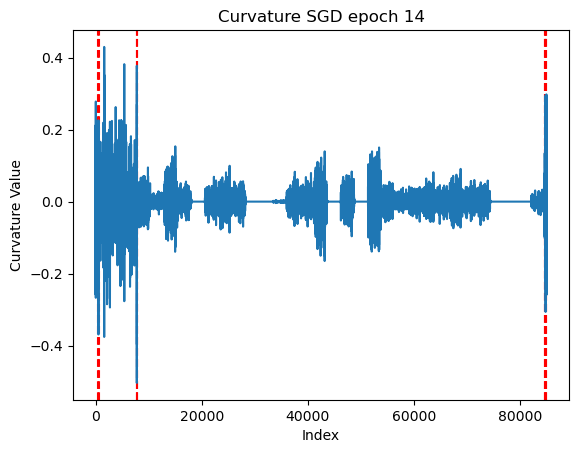

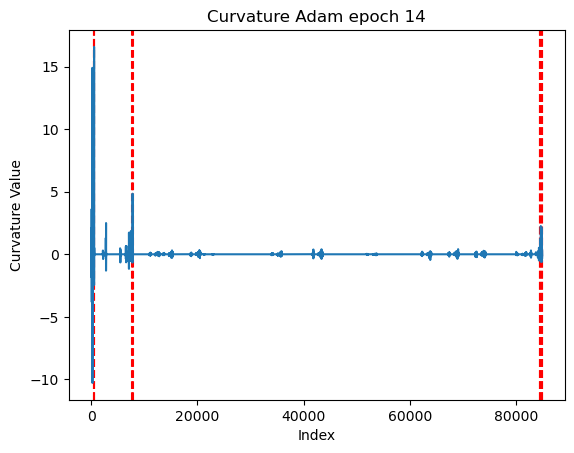

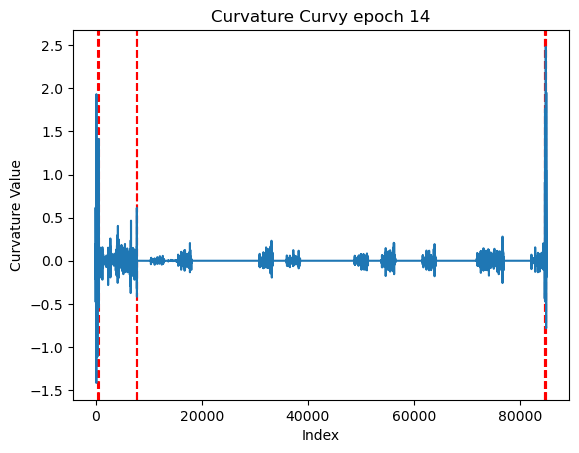

Epoch [15/30], Loss SGD: 2.2912, Loss Adam: 0.9505, loss Curvy: 1.7868


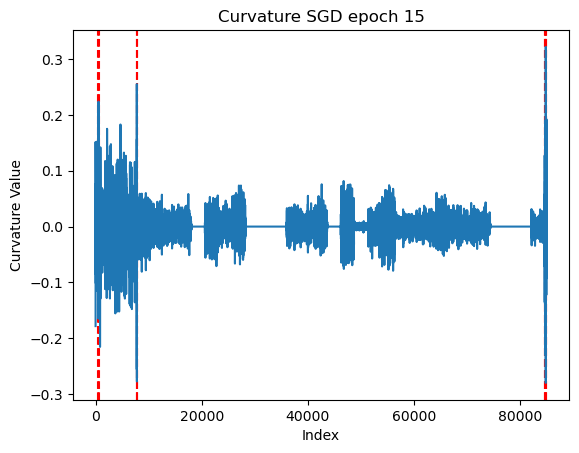

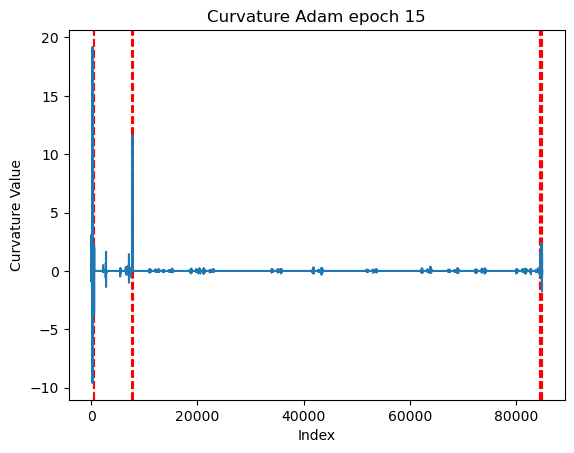

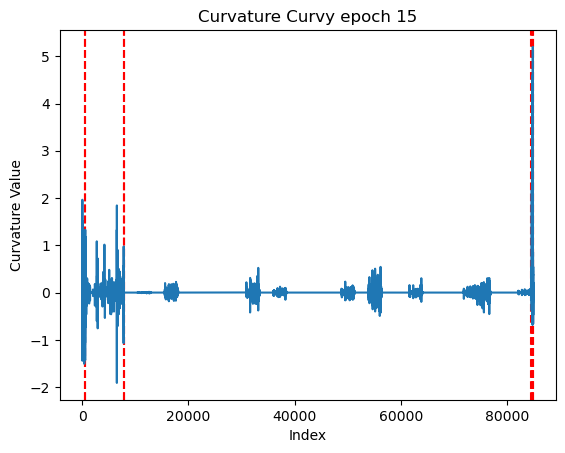

Epoch [16/30], Loss SGD: 2.2892, Loss Adam: 0.8576, loss Curvy: 1.2388


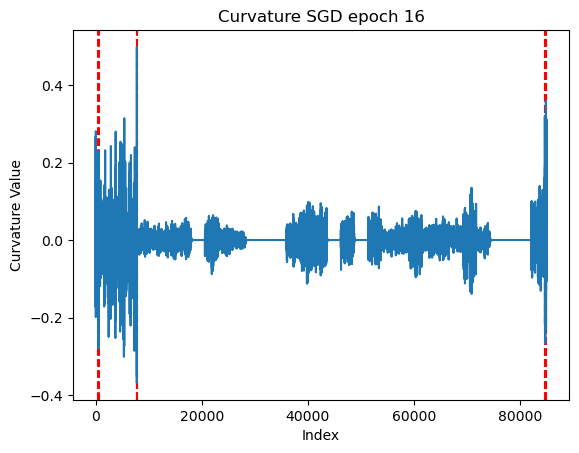

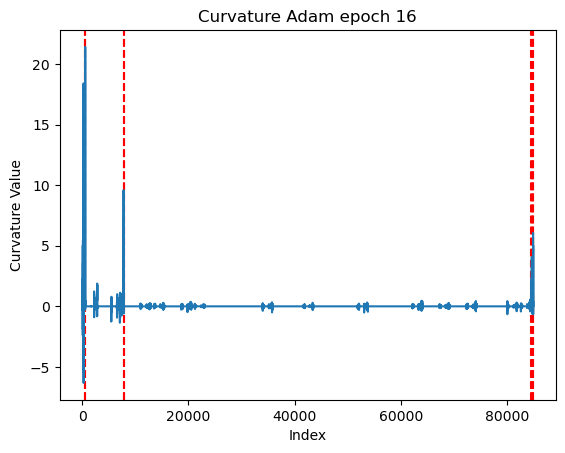

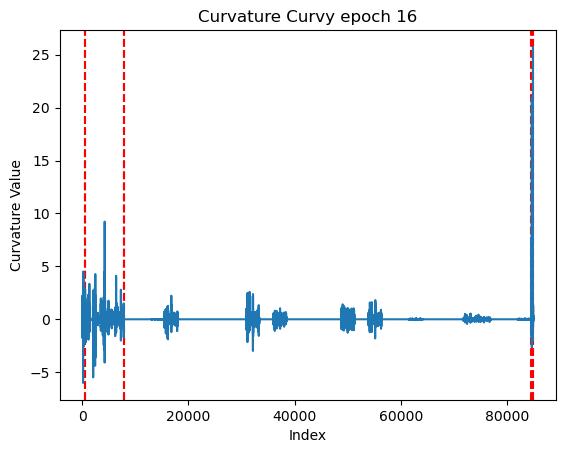

Epoch [17/30], Loss SGD: 2.2892, Loss Adam: 0.8625, loss Curvy: 1.4493


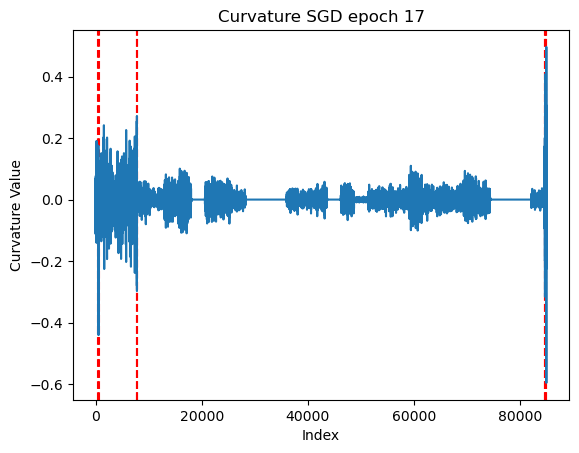

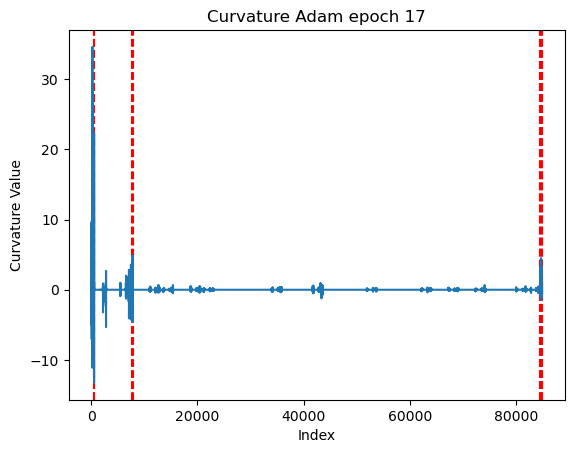

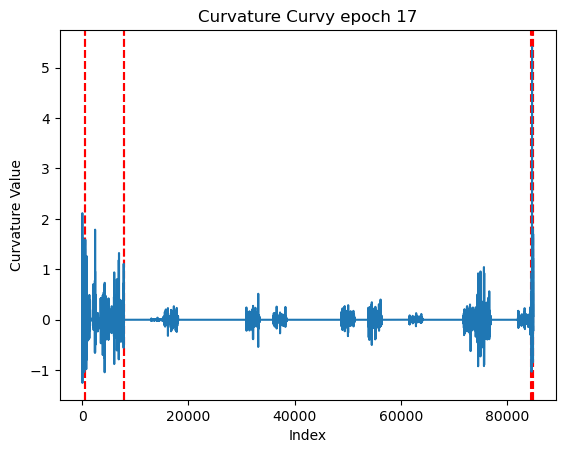

Epoch [18/30], Loss SGD: 2.2860, Loss Adam: 0.7668, loss Curvy: 1.2724


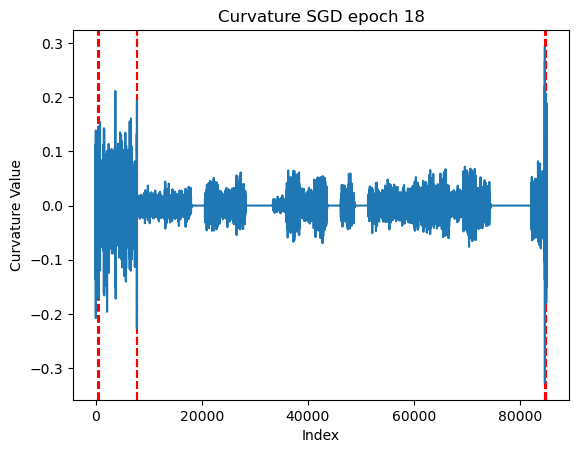

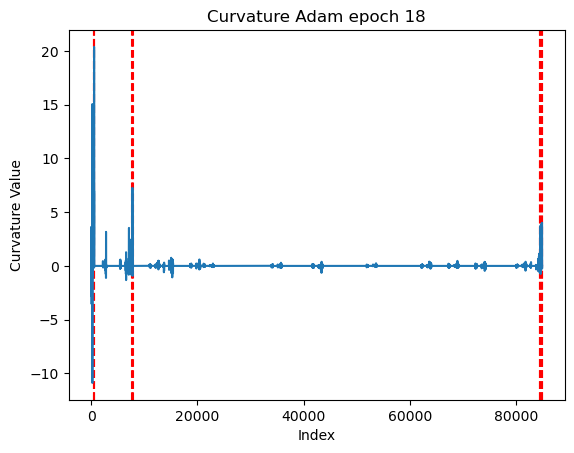

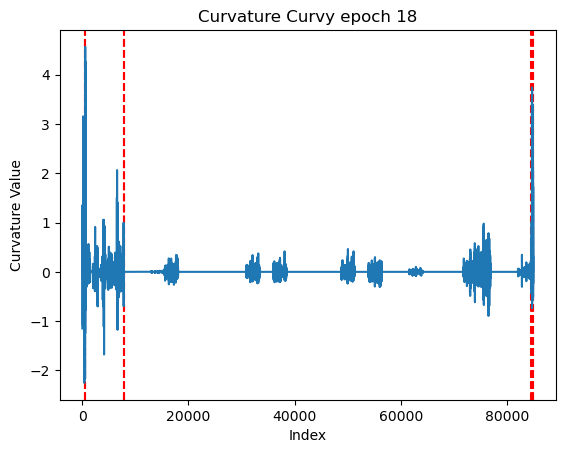

Epoch [19/30], Loss SGD: 2.2825, Loss Adam: 0.6199, loss Curvy: 0.9141


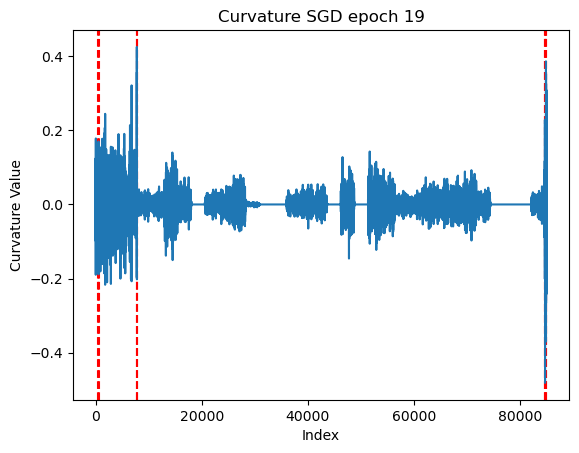

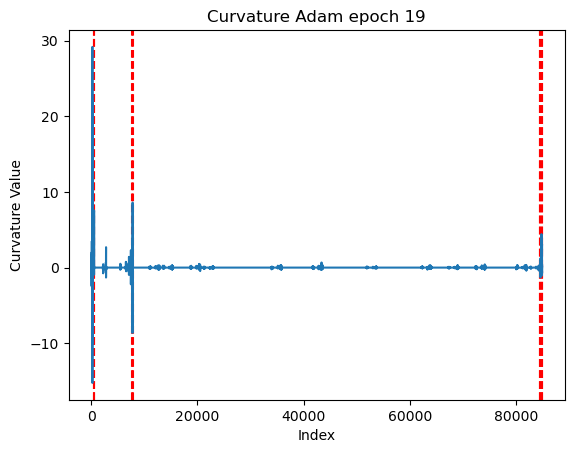

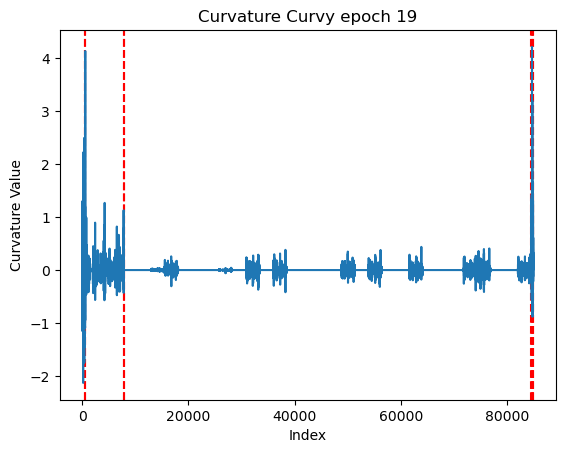

Epoch [20/30], Loss SGD: 2.2802, Loss Adam: 0.5865, loss Curvy: 1.3228


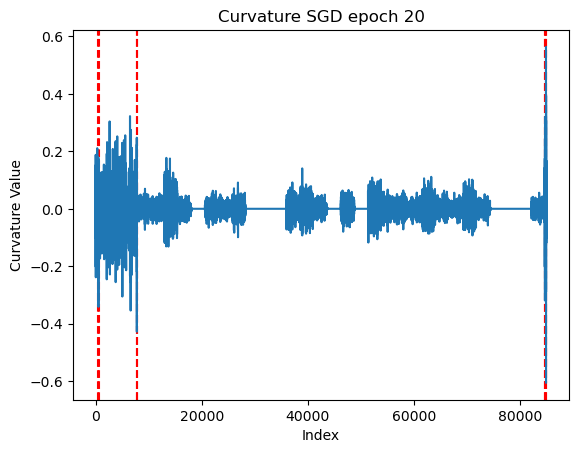

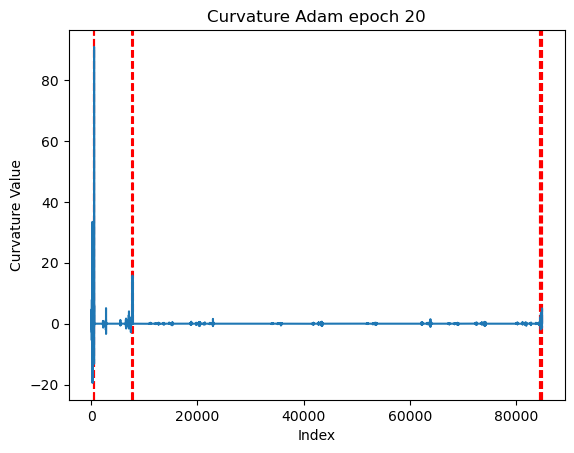

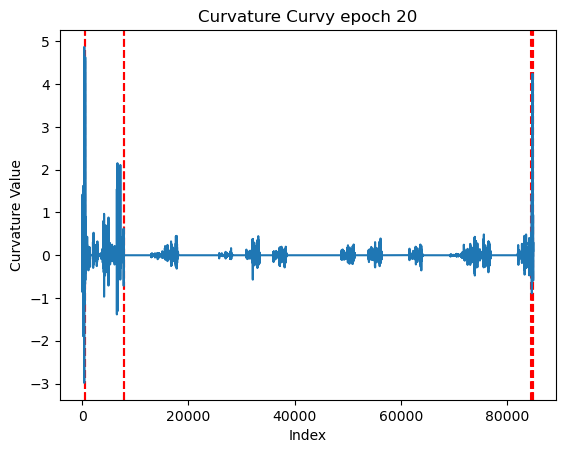

Epoch [21/30], Loss SGD: 2.2762, Loss Adam: 0.5037, loss Curvy: 1.2324


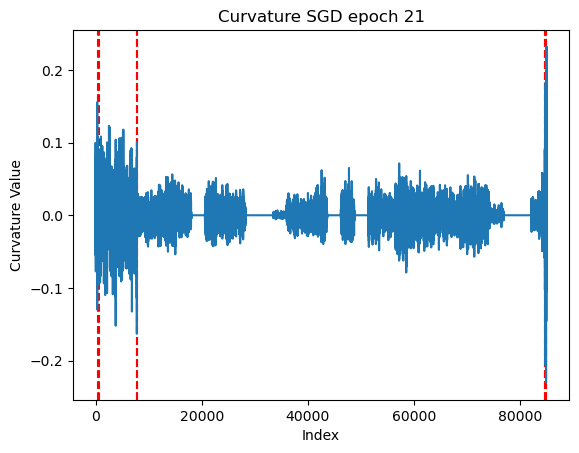

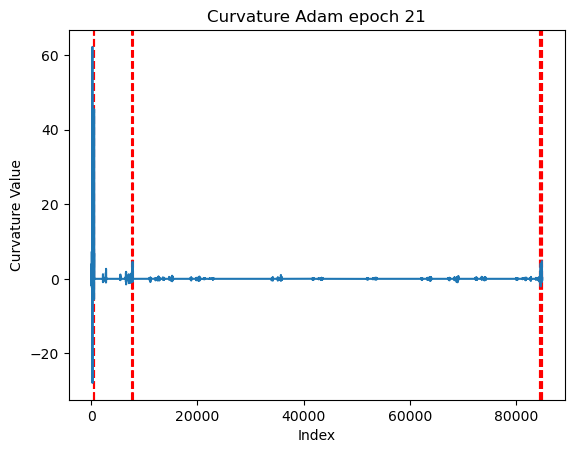

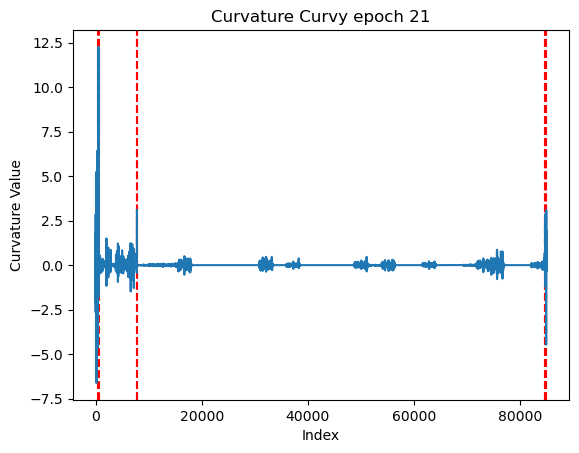

Epoch [22/30], Loss SGD: 2.2713, Loss Adam: 0.4743, loss Curvy: 1.1884


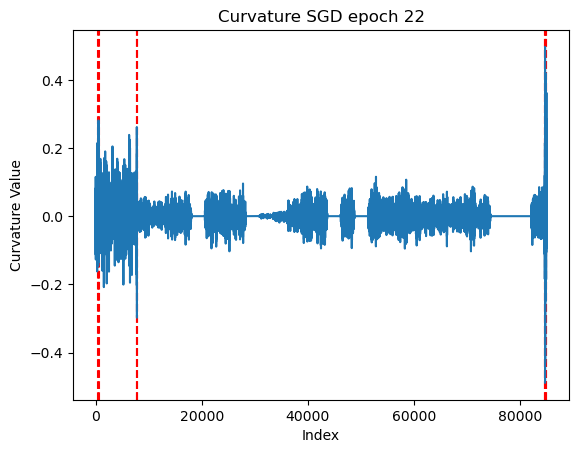

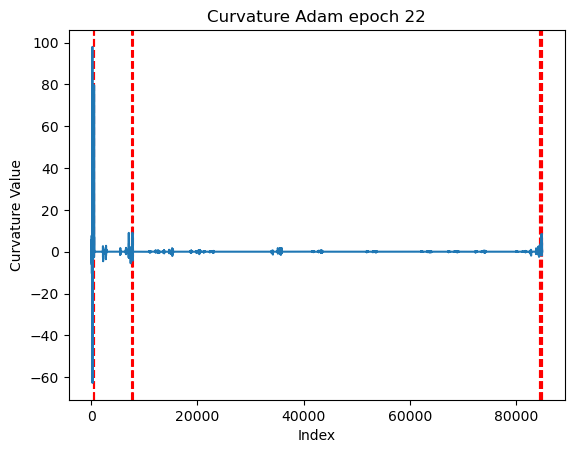

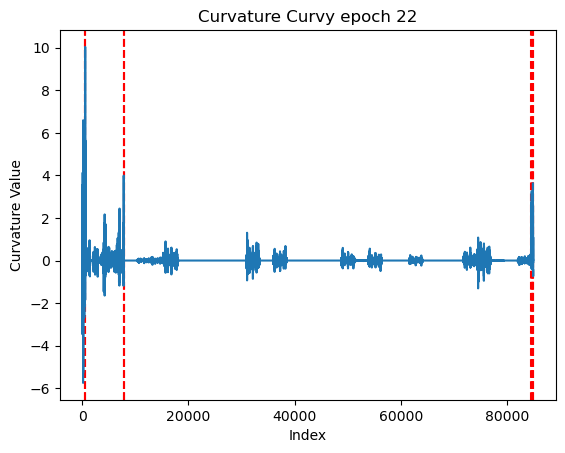

Epoch [23/30], Loss SGD: 2.2667, Loss Adam: 0.5474, loss Curvy: 1.5253


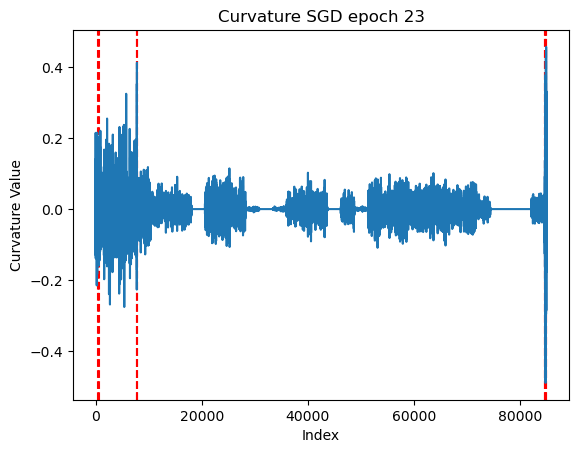

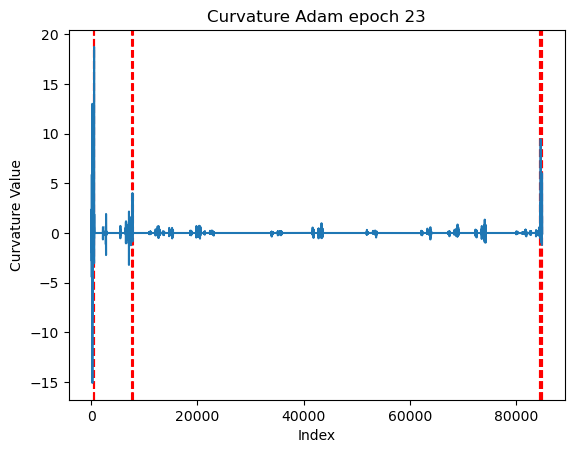

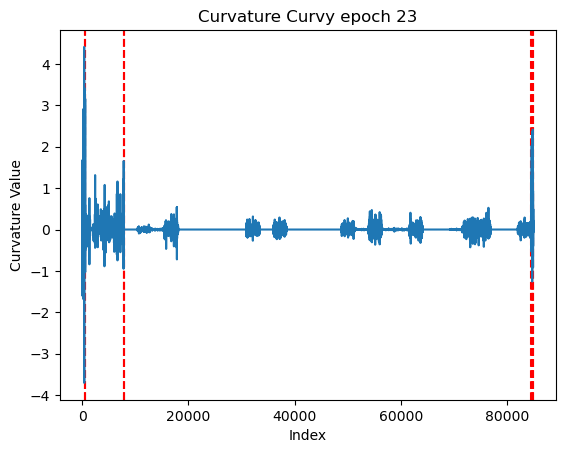

Epoch [24/30], Loss SGD: 2.2567, Loss Adam: 0.4593, loss Curvy: 0.4453


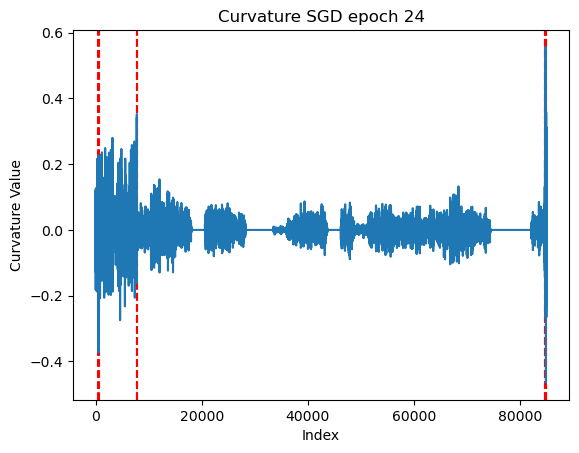

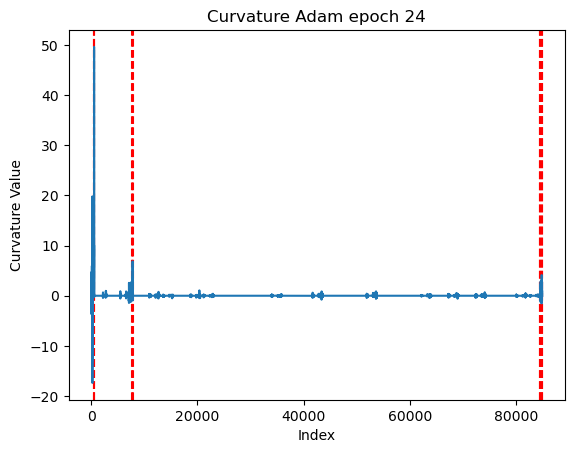

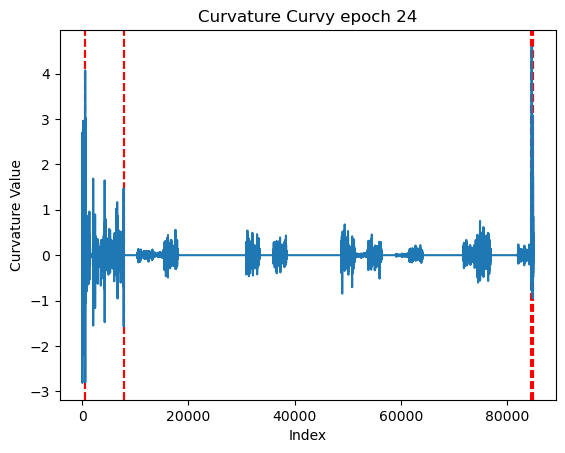

Epoch [25/30], Loss SGD: 2.2514, Loss Adam: 0.5803, loss Curvy: 0.8323


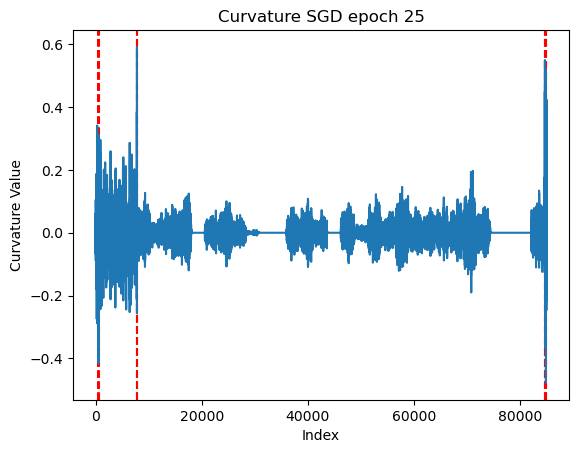

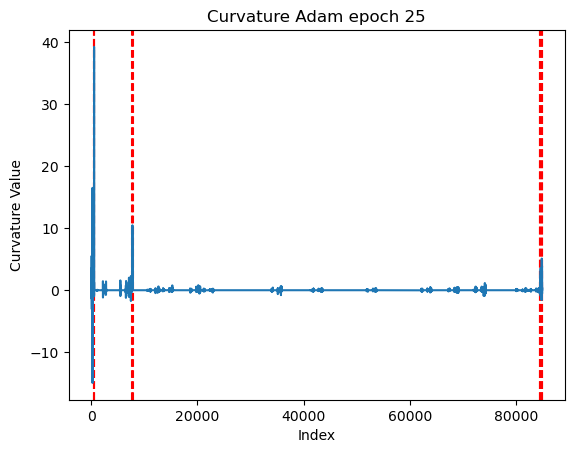

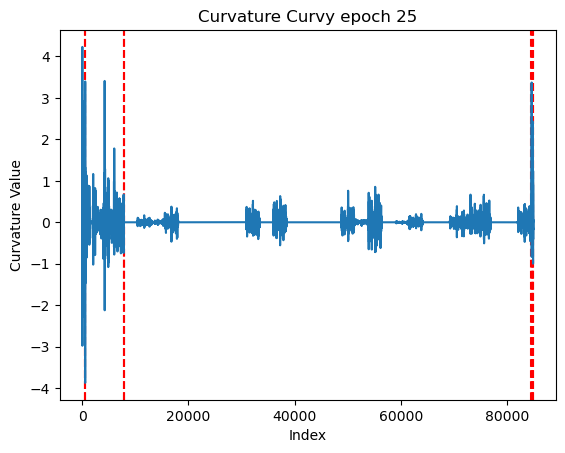

Epoch [26/30], Loss SGD: 2.2414, Loss Adam: 0.4995, loss Curvy: 0.4747


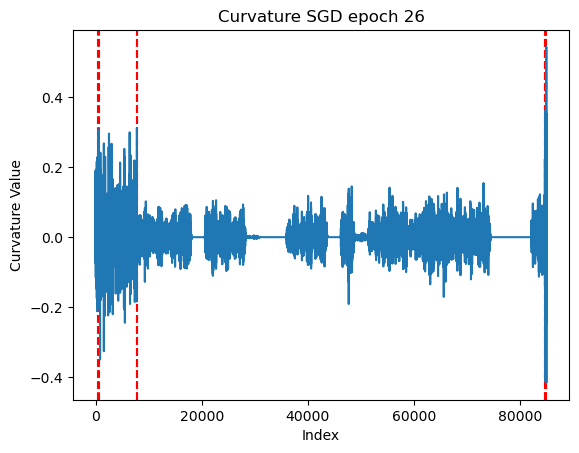

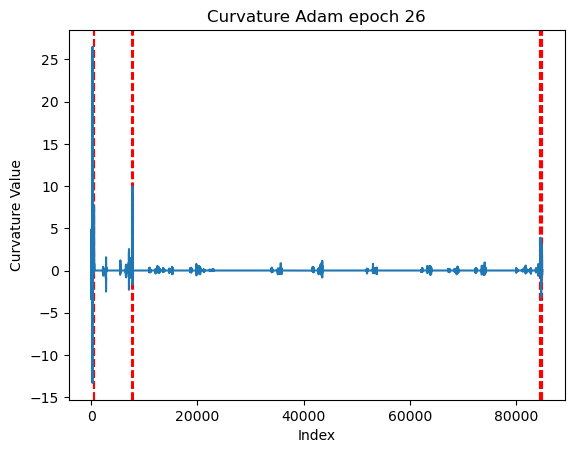

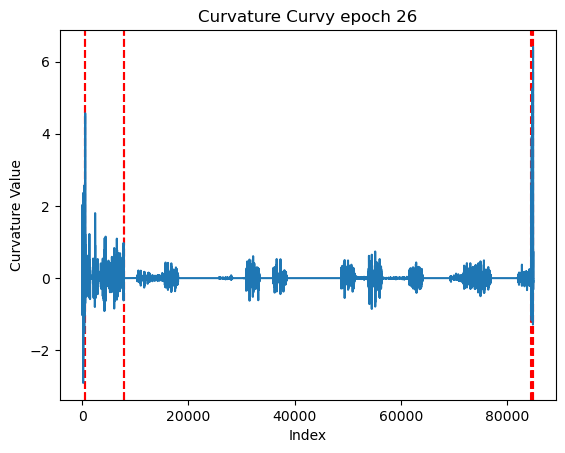

Epoch [27/30], Loss SGD: 2.2267, Loss Adam: 0.4092, loss Curvy: 0.3529


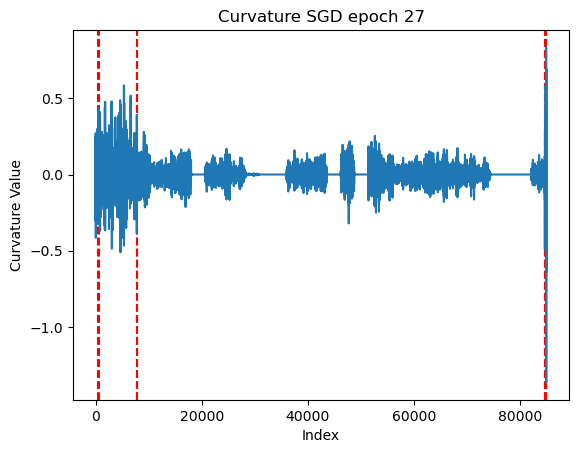

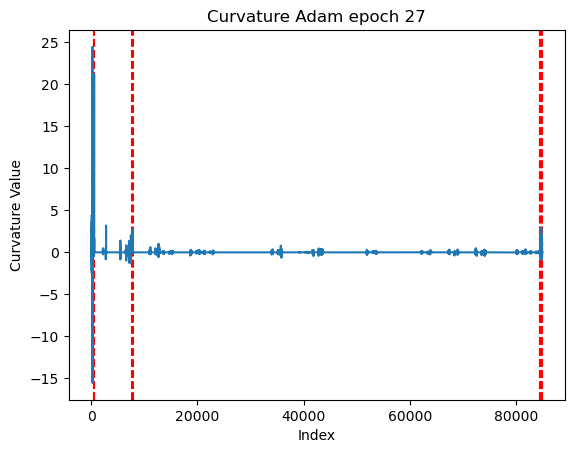

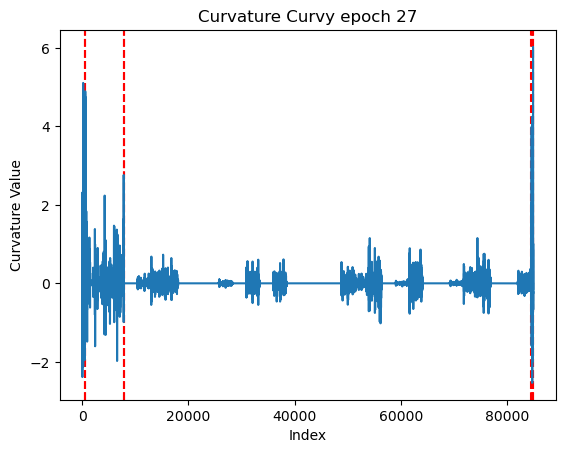

Epoch [28/30], Loss SGD: 2.2125, Loss Adam: 0.3935, loss Curvy: 0.5207


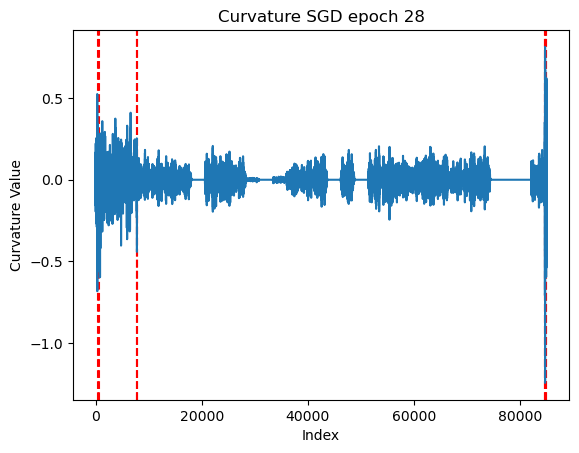

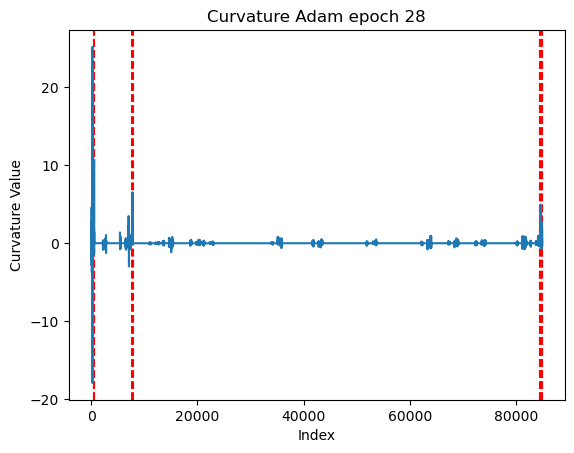

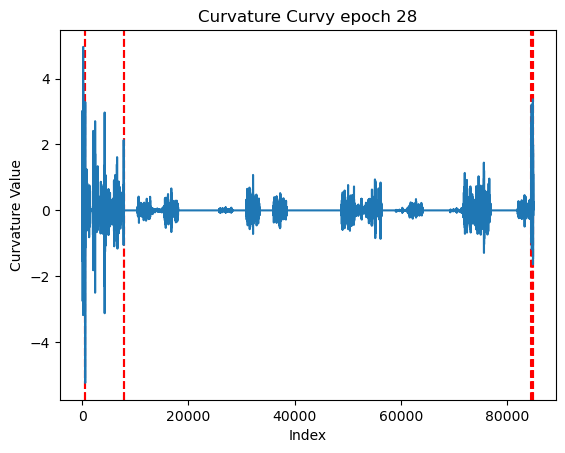

Epoch [29/30], Loss SGD: 2.1965, Loss Adam: 0.2828, loss Curvy: 0.6395


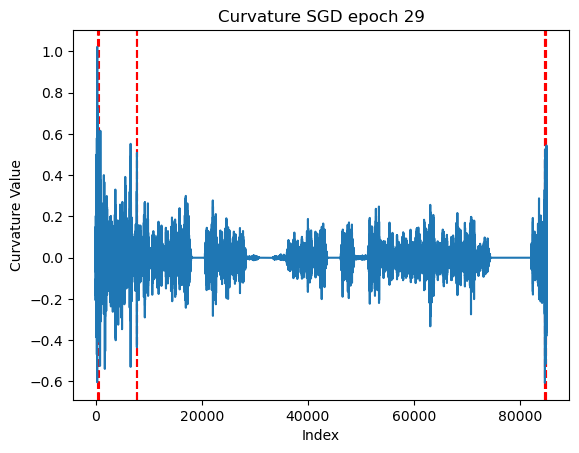

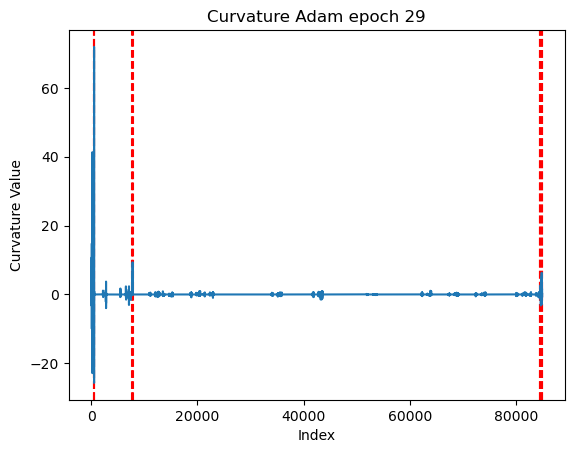

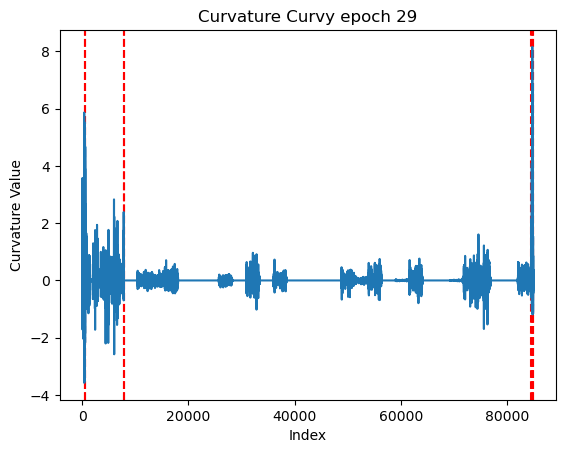

Epoch [30/30], Loss SGD: 2.1738, Loss Adam: 0.2735, loss Curvy: 0.4182


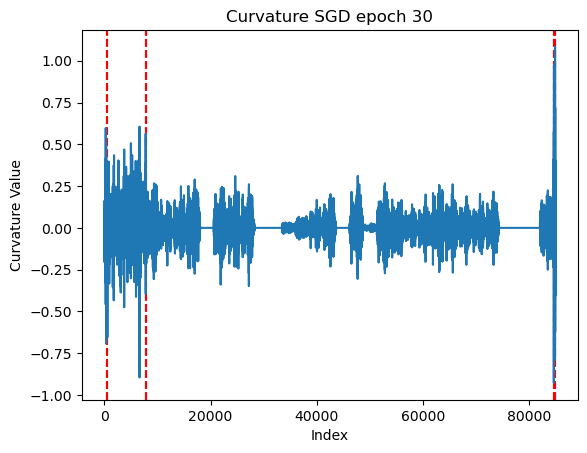

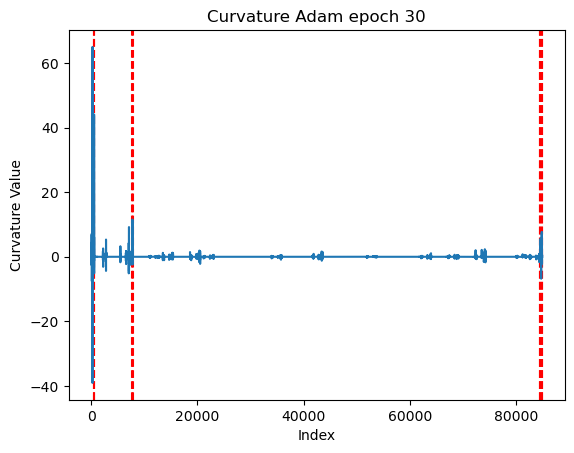

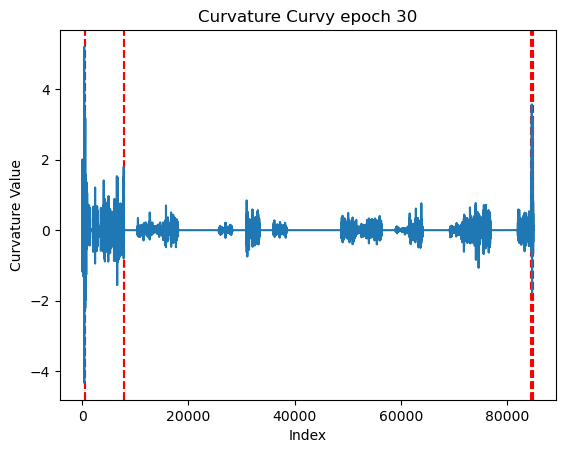

In [53]:
epochs = 30
for epoch in range(epochs):
    model_SGD.train()
    model_Adam.train()
    model_curvy.train()

    running_loss_SGD = 0.0
    running_loss_Adam = 0.0
    running_loss_curvy = 0.0

    for i, (inputs, labels) in enumerate(dataloader):
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer_SGD.zero_grad()
        optimizer_Adam.zero_grad()
        optimizer_curvy.zero_grad()

        # Forward pass
        outputs_SGD = model_SGD(inputs)
        outputs_Adam = model_Adam(inputs)
        outputs_curvy = model_curvy(inputs)

        # Compute loss
        loss_SGD = criterion(outputs_SGD, labels)
        loss_Adam = criterion(outputs_Adam, labels)
        loss_curvy = criterion(outputs_curvy, labels)

        # Backward pass and optimize
        loss_SGD.backward()
        loss_Adam.backward()
        loss_curvy.backward()

        # parami = 0
        for param, cur in zip(model_curvy.parameters(), mean_curvature_curvy):
            # if parami == 4:
            #     break
            if param.grad is None:
                continue
            h_tensor = torch.from_numpy(cur).to(param.device).to(param.dtype)
            param.grad = param.grad/(abs(h_tensor)+1e-2)
            # parami += 1

                

        optimizer_SGD.step()
        optimizer_Adam.step()
        optimizer_curvy.step()


        running_loss_SGD += loss_SGD.item()
        running_loss_Adam += loss_Adam.item()
        running_loss_curvy += loss_curvy.item()

    train_losses_SGD.append(running_loss_SGD / len(dataloader))
    train_losses_Adam.append(running_loss_Adam / len(dataloader))
    train_losses_curvy.append(loss_curvy.item())

    model_distance_SGD.append(distance(model_SGD, model_base))
    model_distance_Adam.append(distance(model_Adam, model_base))
    model_distance_curvy.append(distance(model_curvy, model_base))

    print(f"Epoch [{epoch+1}/{epochs}], Loss SGD: {train_losses_SGD[-1]:.4f}, Loss Adam: {train_losses_Adam[-1]:.4f}, loss Curvy: {train_losses_curvy[-1]:.4f}")
    # Plot curvature array

    indices = torch.randperm(train_X.size(0))[:50]
    random_hessian_loader = (train_X[indices], train_y[indices])

    hessian_SGD = hessian(model_SGD, criterion, data = random_hessian_loader, cuda=cuda)
    hessian_Adam = hessian(model_Adam, criterion, data = random_hessian_loader, cuda=cuda)
    hessian_curvy = hessian(model_curvy, criterion, data = random_hessian_loader, cuda=cuda)

    curvature_SGD = hessian_SGD.curvature_array(n_iter, 1e-3)
    curvature_Adam = hessian_Adam.curvature_array(n_iter, 1e-3)
    curvature_curvy = hessian_curvy.curvature_array(n_iter, 1e-3)

    mean_curvature_SGD = mean_curvature(curvature_SGD)
    mean_curvature_Adam = mean_curvature(curvature_Adam)
    mean_curvature_curvy = mean_curvature(curvature_curvy)
    
    plot_curvature(mean_curvature_SGD, title = f'Curvature SGD epoch {epoch+1}')
    plot_curvature(mean_curvature_Adam, title = f'Curvature Adam epoch {epoch+1}')
    plot_curvature(mean_curvature_curvy, title = f'Curvature Curvy epoch {epoch+1}')

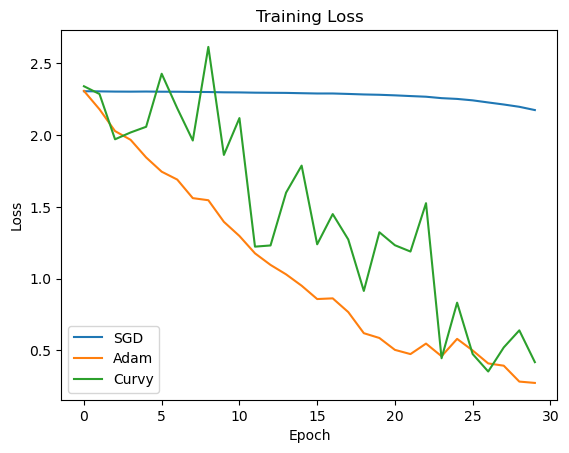

In [54]:
plt.plot(train_losses_SGD, label='SGD')
plt.plot(train_losses_Adam, label='Adam')
plt.plot(train_losses_curvy, label='Curvy')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.show()

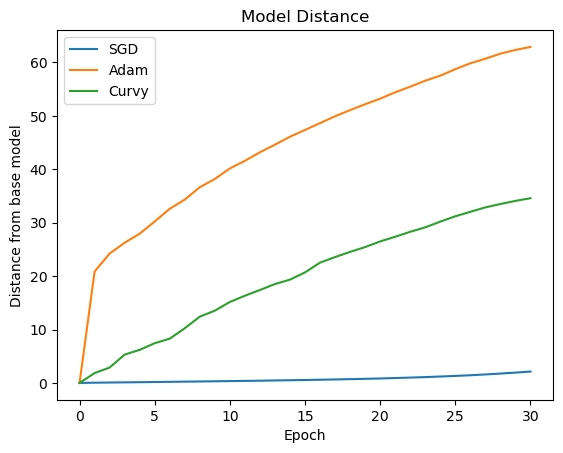

In [58]:
plt.plot([model_distance_SGD[i].detach().item() for i in range(len(model_distance_SGD))], label='SGD')
plt.plot([model_distance_Adam[i].detach().item() for i in range(len(model_distance_Adam))], label='Adam')
plt.plot([model_distance_curvy[i].detach().item() for i in range(len(model_distance_curvy))], label='Curvy')
plt.xlabel('Epoch')
plt.ylabel('Distance from base model')
plt.title('Model Distance')
plt.legend()
plt.show()